In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
#Load the cleaned CSV and parse data column
df = pd.read_csv("sales_transactions_cleaned.csv", parse_dates = ["order_date"])

#List the columns required for the analysis
required_columns = [
    "order_id", "order_date","region_reporting","channel","customer_type",
    "category","product","qty","discount","status","unit_price",
    "net_revenue","net_cost","gross_profit","cost_imputed_flag"
]

#Find any required columns that are missing
missing_columns = [
    column for column in required_columns
    if column not in df.columns
]

#Stpo if a required column is missing
assert not missing_columns, missing_columns

#Print basic checks without cleaning the data again
print("Shape:", df.shape)
print("Date range:", df["order_date"].min(), "to", df["order_date"].max())
display(df["status"].value_counts().to_frame("rows"))

Shape: (7127, 39)
Date range: 2024-09-01 00:00:00 to 2026-09-15 00:00:00


,rows
status,
Completed,6784
Cancelled,210
Returned,133


In [3]:
#Assign a September to August fiscal year
df["fiscal_year"] = np.where(
    df["order_date"].dt.month >= 9,
    df["order_date"].dt.year + 1,
    df["order_date"].dt.year
).astype(int)

#Create a monthly period for trend analysis
df["year_month"] = df["order_date"].dt.to_period("M")

#Keep returns negative but set cancelled quantities to zero
df["net_qty"] = df["qty"]
df.loc[df["status"].eq("Cancelled"),"net_qty"] = 0

#Exclude cancelled orders from the active-order count
df["active_order_id"] = df["order_id"].where(
    ~df["status"].eq("Cancelled")
)

#Keep only the two complete fiscal years
analysis_df = df[df["fiscal_year"].isin([2025,2026])].copy()

#Check the start date, end date, and row count of each fiscal year
fy_coverage = (
    analysis_df.groupby("fiscal_year", as_index = False)
    .agg(
        start_date = ("order_date", "min"),
        end_date = ("order_date", "max"),
        rows = ("order_id", "size")
    )
)

display(fy_coverage)

,fiscal_year,start_date,end_date,rows
0,2025,2024-09-01,2025-08-31,3311
1,2026,2025-09-01,2026-08-31,3662


In [4]:
def summarize_performance(data, group_columns):
    #Sum the main metrics for each requested group
    summary = (
        data.groupby(group_columns, as_index = False, observed = True)
        .agg(
            net_revenue = ("net_revenue", "sum"),
            gross_profit = ("gross_profit", "sum"),
            net_cost = ("net_cost", "sum"),
            net_qty = ("net_qty","sum"),
            active_orders = ("active_order_id", "nunique")
        )
    )

    #Calculate margin from total profit and total revenue
    summary["gross_margin"] = (
        summary["gross_profit"] / summary["net_revenue"].replace(0,np.nan)
    ) 

    #Calculate average selling price per net unit
    summary["average_selling_price"] = (
        summary["net_revenue"] / summary["net_qty"].replace(0, np.nan)
    )

    #Calculate average cost per net unit
    summary["average_unit_cost"] = (
        summary["net_cost"] / summary["net_qty"].replace(0, np.nan)
    )

    return summary

In [5]:
#Summarize the main metrics by fiscal year
fy_summary = summarize_performance(
    analysis_df,
    ["fiscal_year"]
)

#Make FY 2025 and FY 2026 side by side
fy_comparison = fy_summary.set_index("fiscal_year").T

#Calculate the absolute difference between the fiscal years
fy_comparison["absolute_change"] = (
    fy_comparison[2026] - fy_comparison[2025]
)

#Calculate the percentage change from FY 2025
fy_comparison["percentage_change"] = (
    fy_comparison["absolute_change"] / fy_comparison[2025].replace(0, np.nan) * 100
)

#Display the totals and comparison tables
display(fy_summary)
display(fy_comparison)

,fiscal_year,net_revenue,gross_profit,net_cost,net_qty,active_orders,gross_margin,average_selling_price,average_unit_cost
0,2025,2.840882e+10,4.139458e+09,2.426936e+10,17011,3216,0.145710,1.670026e+06,1.426686e+06
1,2026,3.149709e+10,3.699889e+09,2.779720e+10,19808,3550,0.117468,1.590120e+06,1.403332e+06


fiscal_year,2025,2026,absolute_change,percentage_change
net_revenue,2.840882e+10,3.149709e+10,3.088274e+09,10.870832
gross_profit,4.139458e+09,3.699889e+09,-4.395684e+08,-10.618986
net_cost,2.426936e+10,2.779720e+10,3.527843e+09,14.536203
net_qty,1.701100e+04,1.980800e+04,2.797000e+03,16.442302
active_orders,3.216000e+03,3.550000e+03,3.340000e+02,10.385572
gross_margin,1.457103e-01,1.174677e-01,-2.824267e-02,-19.382752
average_selling_price,1.670026e+06,1.590120e+06,-7.990654e+04,-4.784748
average_unit_cost,1.426686e+06,1.403332e+06,-2.335410e+04,-1.636948


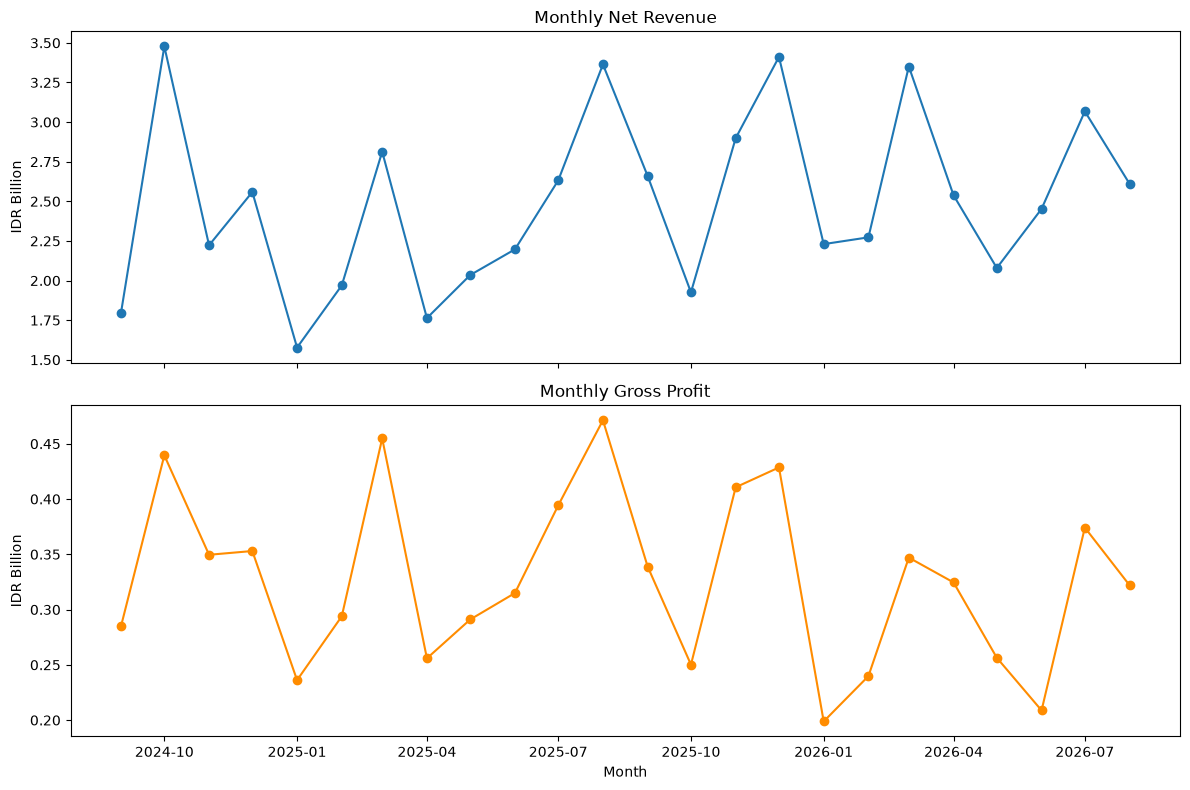

,year_month,net_revenue,gross_profit,net_cost,net_qty,active_orders,gross_margin,average_selling_price,average_unit_cost,month_date
0,2024-09,1.798231e+09,285066800.0,1.513164e+09,1308,242,0.158526,1.374794e+06,1.156853e+06,2024-09-01
1,2024-10,3.477732e+09,439519500.0,3.038212e+09,1134,226,0.126381,3.066783e+06,2.679200e+06,2024-10-01
2,2024-11,2.222648e+09,349582100.0,1.873065e+09,1457,282,0.157282,1.525496e+06,1.285563e+06,2024-11-01
3,2024-12,2.558929e+09,352981750.0,2.205948e+09,1538,341,0.137941,1.663803e+06,1.434296e+06,2024-12-01
4,2025-01,1.577241e+09,236160450.0,1.341080e+09,1244,217,0.149730,1.267878e+06,1.078039e+06,2025-01-01
5,2025-02,1.969671e+09,293955050.0,1.675716e+09,1335,251,0.149241,1.475409e+06,1.255218e+06,2025-02-01
6,2025-03,2.813316e+09,454806450.0,2.358509e+09,1912,378,0.161662,1.471399e+06,1.233530e+06,2025-03-01
7,2025-04,1.763232e+09,255900350.0,1.507332e+09,1060,208,0.145131,1.663427e+06,1.422011e+06,2025-04-01
8,2025-05,2.034898e+09,291040650.0,1.743857e+09,1178,269,0.143025,1.727418e+06,1.480354e+06,2025-05-01
9,2025-06,2.197033e+09,314944000.0,1.882089e+09,1268,241,0.143350,1.732676e+06,1.484298e+06,2025-06-01


In [6]:
#Summarize performance for each month
monthly = summarize_performance(
    analysis_df,
    ["year_month"]
)

#Convert monthly periods into dates for plotting
monthly["month_date"] = monthly["year_month"].dt.to_timestamp()

#Create two charts that share the same month axis
fig, axes = plt.subplots(2, 1, figsize = (12,8), sharex = True)

#Plot monthly net revenue in IDR Billions
axes[0].plot(
    monthly["month_date"],
    monthly["net_revenue"] / 1_000_000_000,
    marker = "o",
)

axes[0].set_title("Monthly Net Revenue")
axes[0].set_ylabel("IDR Billion")

#Plot monthly gross profit in IDR Billions
axes[1].plot(
    monthly["month_date"],
    monthly["gross_profit"] / 1_000_000_000,
    marker = "o",
    color = "darkorange"
)

axes[1].set_title("Monthly Gross Profit")
axes[1].set_ylabel("IDR Billion")
axes[1].set_xlabel("Month")

plt.tight_layout()
plt.show()

display(monthly)

In [7]:
#Summarize each category by fiscal year
category_by_fy = summarize_performance(
    analysis_df,
    ["fiscal_year", "category"]
)

#Reshape the table so both fiscal years can be compared
category_pivot = category_by_fy.pivot(
    index = "category",
    columns = "fiscal_year",
    values = [
        "net_revenue",
        "gross_profit",
        "gross_margin",
        "average_selling_price",
        "average_unit_cost"
    ]
)

#Calculate the change in revenue, profit, margin, price, and cost
category_change = pd.DataFrame({
    "revenue_change": (
        category_pivot[("net_revenue", 2026)]
        - category_pivot[("net_revenue", 2025)]
    ),
    "gross_profit_change": (
        category_pivot[("gross_profit", 2026)]
        - category_pivot[("gross_profit", 2025)]
    ),
    "fy2025_margin_pct": (category_pivot[("gross_margin", 2025)] * 100),
    "fy2026_margin_pct": (category_pivot[("gross_margin", 2026)] * 100),
    "margin_change_pp": (
        category_pivot[("gross_margin",2026)]
        - category_pivot[("gross_margin", 2025)]
    ) * 100,
    "selling_price_change": (
        category_pivot[("average_selling_price", 2026)]
        - category_pivot[("average_selling_price", 2025)]
    ),
    "unit_cost_change": (
        category_pivot[("average_unit_cost", 2026)]
        - category_pivot[("average_unit_cost", 2025)]
    )
}).sort_values("gross_profit_change")

display(category_change)

,revenue_change,gross_profit_change,fy2025_margin_pct,fy2026_margin_pct,margin_change_pp,selling_price_change,unit_cost_change
category,,,,,,,
Laptop,1.537280e+09,-362058250.0,7.501636,4.263590,-3.238046,-465067.201261,-153758.361723
Smartphone,5.414600e+08,-212414900.0,9.102310,4.837900,-4.264411,-133884.610793,43516.797994
Printer & Tinta,1.209152e+08,-22745850.0,17.248915,14.860148,-2.388767,-301579.424460,-227154.073101
Aksesoris,3.355470e+07,-13994100.0,35.249268,34.205021,-1.044246,-10641.297803,-3060.314419
Networking,3.147885e+08,47441750.0,26.470241,24.934169,-1.536072,-34972.007533,-14180.431400
Peralatan Kantor,5.402761e+08,124202900.0,27.612095,26.985006,-0.627088,-73214.340620,-47681.458795


In [8]:
#Group discount values into clear reporting bands
analysis_df["discount_band"] = pd.cut(
    analysis_df["discount"],
    bins = [-0.001, 0, 0.05, 0.10, 0.15, 1],
    labels = ["0%", "1-5%", "6-10%", "11-15%", ">15%"]
)

#Summarize performance by fiscal year and discount band
discount_summary = summarize_performance(
    analysis_df,
    ["fiscal_year","discount_band"]
)

#Summarize performance by fiscal year and sales channel
channel_summary = summarize_performance(
    analysis_df,
    ["fiscal_year","channel"]
)

display(discount_summary)
display(channel_summary)

,fiscal_year,discount_band,net_revenue,gross_profit,net_cost,net_qty,active_orders,gross_margin,average_selling_price,average_unit_cost
0,2025,0%,1.357588e+10,2.232462e+09,1.134342e+10,6779,1517,0.164443,2.002638e+06,1.673318e+06
1,2025,1-5%,7.635554e+09,1.047185e+09,6.588369e+09,4559,1007,0.137146,1.674831e+06,1.445135e+06
2,2025,6-10%,6.022090e+09,7.040752e+08,5.318014e+09,4445,596,0.116915,1.354801e+06,1.196404e+06
3,2025,11-15%,1.175287e+09,1.557351e+08,1.019552e+09,1228,96,0.132508,9.570740e+05,8.302539e+05
4,2026,0%,1.390464e+10,2.485742e+09,1.141889e+10,7684,1471,0.178771,1.809557e+06,1.486061e+06
5,2026,1-5%,7.351694e+09,9.679408e+08,6.383753e+09,4288,900,0.131662,1.714481e+06,1.488748e+06
6,2026,6-10%,4.912151e+09,5.307248e+08,4.381427e+09,3806,491,0.108043,1.290634e+06,1.151189e+06
7,2026,11-15%,1.736788e+09,7.996060e+07,1.656827e+09,1293,100,0.046039,1.343224e+06,1.281382e+06
8,2026,>15%,3.591822e+09,-3.644786e+08,3.956300e+09,2737,588,-0.101475,1.312321e+06,1.445488e+06


,fiscal_year,channel,net_revenue,gross_profit,net_cost,net_qty,active_orders,gross_margin,average_selling_price,average_unit_cost
0,2025,Offline,1.842037e+10,2.751044e+09,1.566932e+10,10566,2122,0.149348,1.743363e+06,1.482995e+06
1,2025,Online,9.988446e+09,1.388413e+09,8.600033e+09,6445,1094,0.139002,1.549798e+06,1.334373e+06
2,2026,Offline,2.056495e+10,3.070957e+09,1.749399e+10,12614,2175,0.149330,1.630327e+06,1.386871e+06
3,2026,Online,1.093214e+10,6.289323e+08,1.030321e+10,7194,1375,0.057531,1.519620e+06,1.432195e+06


In [9]:
#Laptop only transactions
laptop_df = analysis_df.loc[analysis_df["category"] == "Laptop"]

#Calculate each product's totals and ratios by fiscal year
laptop_summary = summarize_performance(
    laptop_df, ["product", "fiscal_year"]
)

#Show gross margin as percentage
laptop_summary["gross_margin_pct"] = laptop_summary["gross_margin"] * 100

#Place the 2025 and 2026 years side by side for each metrics
laptop_comparison = laptop_summary.pivot(
    index = "product",
    columns = "fiscal_year",
    values = [
        "net_qty",
        "net_revenue",
        "gross_profit",
        "gross_margin_pct",
        "average_selling_price",
        "average_unit_cost"
    ]
)

display(laptop_comparison)

net_qty          net_revenue               gross_profit  \
fiscal_year           2025   2026          2025          2026         2025   
product                                                                      
Laptop Axio 14       654.0  513.0  5.390275e+09  4.089775e+09  427186800.0   
Laptop Axio Pro 15   449.0  572.0  5.632250e+09  6.875700e+09  402045900.0   
Laptop Veno 13       364.0  642.0  2.183020e+09  3.777350e+09  161399200.0   

                                gross_margin_pct            \
fiscal_year                2026             2025      2026   
product                                                      
Laptop Axio 14      194287800.0         7.925139  4.750574   
Laptop Axio Pro 15  213392050.0         7.138282  3.103568   
Laptop Veno 13      220893800.0         7.393391  5.847851   

                   average_selling_price               average_unit_cost  \
fiscal_year                         2025          2026              2025   
product                                                                    
Laptop Axio 14              8.242011e+06  7.972271e+06      7.588820e+06   
Laptop Axio Pro 15          1.254399e+07  1.202045e+07      1.164856e+07   
Laptop Veno 13              5.997308e+06  5.883723e+06      5.553903e+06   

                                  
fiscal_year                 2026  
product                           
Laptop Axio 14      7.593542e+06  
Laptop Axio Pro 15  1.164739e+07  
Laptop Veno 13      5.539651e+06

### Descriptive analysis — What happened?

- **Revenue grew 10.87%**, from IDR 28.41 billion in FY2025 to IDR 31.50 billion in FY2026. Net quantity also increased by 16.44%.

- **Gross profit fell 10.62%**, from IDR 4.14 billion to IDR 3.70 billion. Gross margin declined from 14.57% to 11.75%.

- Monthly performance fluctuated. Revenue peaked at IDR 3.48 billion in October 2024, while gross profit reached its lowest point at IDR 198.8 million in January 2026.

### Diagnostic analysis — Why did it happen?

- Average selling price per net unit fell by **4.78%**, while average cost per net unit fell by only **1.64%**. This indicates that selling prices declined faster than costs.

- Laptop and Smartphone gross profit fell by **IDR 362.1 million** and **IDR 212.4 million**, respectively. Online gross margin also dropped sharply from **13.90% to 5.75%**.

- FY2026 sales with discounts above 15% generated **IDR 3.59 billion** in revenue but produced a **gross loss of IDR 364.5 million**.

- **The Laptop supplier-cost claim is not supported.** Laptop revenue increased by IDR 1.54 billion, but its margin fell from 7.50% to 4.26%. Since average unit cost also decreased, lower selling prices were the more likely cause.

**Assumption and limitation:** These comparisons use the net values prepared in Soal 1, including returns and imputed costs. The results show where profitability weakened, but they do not prove that discounts caused the decline.

**Validation:** Compare FY2026 gross profit by channel and discount band together to confirm where the largest losses occurred.

FY revenue growth: 10.87%
Latest complete month: 2026-08


,month,same_month_last_year,last_year_revenue,forecast_revenue,low,high
0,2026-10,2025-10,1.925788e+09,2.135137e+09,1.921623e+09,2.348650e+09
1,2026-11,2025-11,2.898666e+09,3.213775e+09,2.892398e+09,3.535153e+09
2,2026-12,2025-12,3.411196e+09,3.782021e+09,3.403819e+09,4.160224e+09


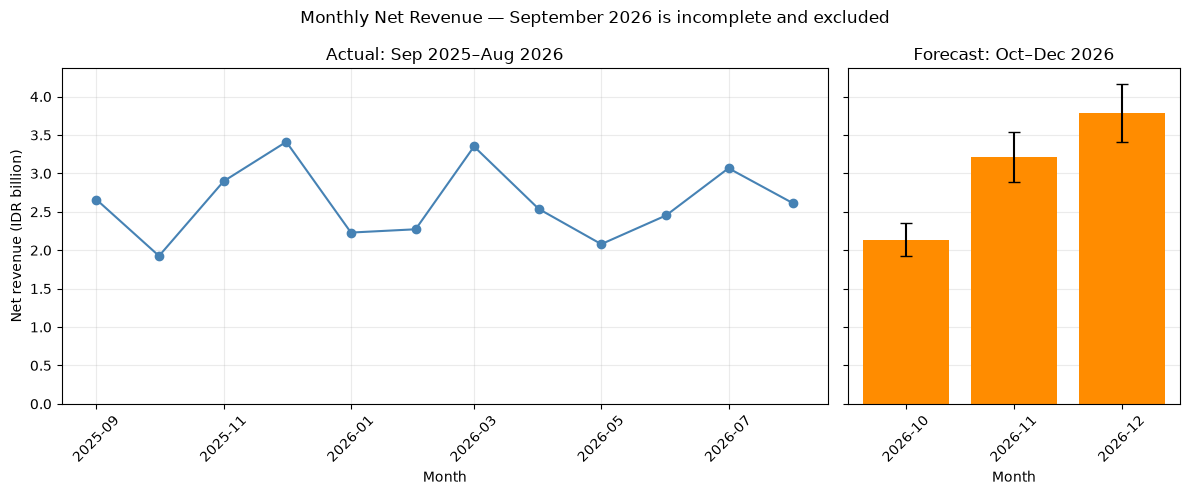

In [10]:
#Calculate FY2026 revenue growth compared with FY2025
fy = summarize_performance(analysis_df, "fiscal_year")
fy = fy.set_index("fiscal_year")

growth_factor = (
    fy.loc[2026, "net_revenue"]
    / fy.loc[2025, "net_revenue"]
)

#Get monthly revenue from complete months only
monthly = summarize_performance(analysis_df, "year_month")
monthly = (
    monthly.set_index("year_month")["net_revenue"]
    .sort_index()
)

#Find the latest dataset month
latest_month = df["order_date"].max().to_period("M")

#Forecast the next three months
forecast_months = pd.period_range(
    start=latest_month + 1,
    periods=3,
    freq="M"
)

last_year_months = forecast_months - 12

#Use the same months last year as the forecast base
forecast = pd.DataFrame({
    "month": forecast_months,
    "same_month_last_year": last_year_months,
    "last_year_revenue": monthly.loc[last_year_months].to_numpy()
})

#Assume each forecast month grows by the FY revenue growth rate
forecast["forecast_revenue"] = (
    forecast["last_year_revenue"] * growth_factor
)

#Add a 10% planning range
forecast["low"] = forecast["forecast_revenue"] * 0.90
forecast["high"] = forecast["forecast_revenue"] * 1.10

print(f"FY revenue growth: {(growth_factor - 1):.2%}")
print("Latest complete month:", monthly.index.max())

display(forecast)

#Show the latest 12 complete actual months
recent_actual = monthly.tail(12)
actual_dates = recent_actual.index.to_timestamp()

#Use the same revenue scale in both panels
fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 5),
    sharey=True,
    gridspec_kw={"width_ratios": [3, 1.3]}
)

#Left panel: actual monthly revenue
axes[0].plot(
    actual_dates,
    recent_actual / 1_000_000_000,
    marker="o",
    color="steelblue"
)
axes[0].set_title("Actual: Sep 2025–Aug 2026")
axes[0].set_ylabel("Net revenue (IDR billion)")
axes[0].set_xlabel("Month")
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(alpha=0.25)

#Right panel: forecast and 10% planning range
forecast_revenue_billion = forecast["forecast_revenue"] / 1_000_000_000
planning_range_billion = (
    forecast["high"] - forecast["forecast_revenue"]
) / 1_000_000_000

axes[1].bar(
    forecast["month"].astype(str),
    forecast_revenue_billion,
    yerr=planning_range_billion,
    capsize=4,
    color="darkorange"
)
axes[1].set_title("Forecast: Oct–Dec 2026")
axes[1].set_xlabel("Month")
axes[1].tick_params(axis="x", rotation=45)
axes[1].set_axisbelow(True)
axes[1].grid(axis="y", alpha=0.25)

fig.suptitle(
    "Monthly Net Revenue — September 2026 is incomplete and excluded"
)
plt.tight_layout()
plt.show()

### Predictive analysis: What is likely to happen next?

* Estimated net revenue is **IDR 2.14 billion in October 2026**, **IDR 3.21 billion in November**, and **IDR 3.78 billion in December**.
* The estimate uses revenue from the **same month in 2025**, multiplied by the **FY2026 versus FY2025 revenue growth factor of 1.109** (about 10.87% growth). Incomplete September 2026 data was excluded.
* The **10% planning ranges** are IDR **1.92–2.35 billion** for October, **2.89–3.54 billion** for November, and **3.40–4.16 billion** for December. These are planning scenarios, not statistical confidence intervals.
* **Assumption and risk:** last year’s monthly pattern and the annual growth rate will continue. Changes in demand, prices, or promotions could make actual revenue differ.
* **Local validation:** October 2025 revenue of IDR 1.926 billion, multiplied by the unrounded growth factor, should give approximately IDR 2.135 billion for October 2026.

In [11]:
#Keeping FY 2026 data only
fy26 = analysis_df[
    analysis_df["fiscal_year"].eq(2026)
].copy()

#Scenario 1 : cap sales discounts at 15% assuming quantity and cost stay unchanged
discounted = fy26[
    fy26["status"].eq("Completed") & fy26["discount"].gt(0.15)
]

discount_impact = (
    discounted["qty"] * discounted["unit_price"] * (discounted["discount"] - 0.15)
).sum()

#Scenario 2 : reduce Laptop cost by 2% assuming Laptop revenue and quantity stay unchanged
laptop_impact = (
    fy26.loc[
        fy26["category"].eq("Laptop"),
        "net_cost"
    ].sum() * 0.02
)

#Scenario 3 : shift 5% of revenue to higher-margin categories assuming total revenue and category margins stay unchanged
category = summarize_performance(
    fy26,
    ["category"]
).set_index("category")

low = category.loc[["Laptop", "Smartphone"]]
high = category.loc[["Aksesoris", "Peralatan Kantor"]]

low_margin = (
    low["gross_profit"].sum()
    / low["net_revenue"].sum()
)

high_margin = (
    high["gross_profit"].sum()
    / high["net_revenue"].sum()
)

shifted_revenue = fy26["net_revenue"].sum() * 0.05
mix_impact = shifted_revenue *(high_margin - low_margin)

#Display the three independent scenarios
scenarios = pd.DataFrame({
    "scenario": [
        "Cap discount at 15%",
        "Reduce Laptop cost by 2%",
        "Shift 5% of revenue",
    ],
    "gross_profit_impact": [
        discount_impact,
        laptop_impact,
        mix_impact
    ]
})

display(scenarios)

,scenario,gross_profit_impact
0,Cap discount at 15%,5.027962e+08
1,Reduce Laptop cost by 2%,2.822850e+08
2,Shift 5% of revenue,3.987218e+08


In [12]:
#Keep completed sales with negative gross profit
negative_margin = fy26[
    fy26["status"].eq("Completed") & fy26["gross_profit"].lt(0)
]

#Summarize them by category
negative_summary = (
    negative_margin.groupby("category", as_index = False)
    .agg(
        rows = ("order_id", "size"),
        gross_profit = ("gross_profit", "sum")
    ).sort_values("gross_profit")
)

print("Negative margin sales:" , len(negative_margin))
display(negative_summary)

Negative margin sales: 325


,category,rows,gross_profit
0,Laptop,145,-364396900.0
3,Smartphone,127,-154965100.0
2,Printer & Tinta,38,-13763600.0
1,Networking,15,-921450.0


### Prescriptive analysis: What should we do?

* **Test a 15% discount cap.** Modeled gross profit impact: **+IDR 502.8 million**, assuming sales quantity does not fall. Start with a limited trial because customers may respond to smaller discounts.
* **Promote Aksesoris and Peralatan Kantor.** Shifting 5% of total revenue toward these higher-margin categories gives a modeled **+IDR 398.7 million**, assuming demand and margins hold.
* **Explore a 2% Laptop cost saving.** Modeled impact: **+IDR 282.3 million**, if suppliers can offer it without affecting sales or quality.

These are **independent what-if scenarios**. Their impacts should not be added together or treated as guaranteed results.


In [13]:
#Check that the flag contains only True or False
assert analysis_df["cost_imputed_flag"].isin([True, False]).all(),(
    "Check missing or unexpected cost_imputed_flag valuse."
)

#Summarize all cleaned rows
all_fy = summarize_performance(analysis_df, "fiscal_year")
all_fy["rows"] = all_fy["fiscal_year"].map(
    analysis_df["fiscal_year"].value_counts()
)
all_fy["data_used"] = "All cleaned rows"

#Summarize only rows with non imputed costs
known_cost_df = analysis_df.loc[analysis_df["cost_imputed_flag"] == False]
known_fy = summarize_performance(known_cost_df, "fiscal_year")
known_fy["rows"] = known_fy["fiscal_year"].map(
    known_cost_df["fiscal_year"].value_counts()
)
known_fy["data_used"] = "Non-imputed cost rows"

#Put both results in one table
fy_cost_check = pd.concat([all_fy, known_fy], ignore_index = True)
fy_cost_check["gross_margin_pct"] = fy_cost_check["gross_margin"] * 100

display(
    fy_cost_check[
        ["fiscal_year", "data_used", "rows", "net_revenue",
         "net_cost", "gross_profit", "gross_margin_pct"
    ]].sort_values(["fiscal_year", "data_used"])
)

#Count FY 2026 imputed cost rows within each category
fy26 = analysis_df.loc[analysis_df["fiscal_year"] == 2026]

imputed_by_category = (
    fy26.groupby("category", as_index = False)
    .agg(
        total_rows = ("cost_imputed_flag", "size"),
        imputed_rows = ("cost_imputed_flag" ,"sum")
    )
)

imputed_by_category["imputed_pct"] = (
    imputed_by_category["imputed_rows"]
    / imputed_by_category["total_rows"]
    * 100 
)

display(
    imputed_by_category.sort_values("imputed_rows", ascending = False)
)

,fiscal_year,data_used,rows,net_revenue,net_cost,gross_profit,gross_margin_pct
0,2025,All cleaned rows,3311,2.840882e+10,2.426936e+10,4.139458e+09,14.571033
2,2025,Non-imputed cost rows,3083,2.723260e+10,2.339330e+10,3.839303e+09,14.098187
1,2026,All cleaned rows,3662,3.149709e+10,2.779720e+10,3.699889e+09,11.746766
3,2026,Non-imputed cost rows,3392,3.008470e+10,2.671898e+10,3.365718e+09,11.187473


,category,total_rows,imputed_rows,imputed_pct
2,Networking,403,244,60.545906
0,Aksesoris,905,9,0.994475
4,Printer & Tinta,444,6,1.351351
5,Smartphone,623,5,0.802568
1,Laptop,721,3,0.416089
3,Peralatan Kantor,566,3,0.530035


### Cost-imputation limitation

* Excluding imputed-cost rows removes **228 FY2025 rows** and **270 FY2026 rows**. Revenue still rises, while gross profit and gross margin still fall.
* This check also removes those rows’ revenue, so it **does not isolate the effect of estimated costs**.
* Networking needs particular caution: **244 of 403 FY2026 rows (60.55%)** have imputed costs.
